# Entrenamiento — MobileNetV2 + TFLite
Pipeline: tf.data en memoria → transfer learning → fine-tuning → TFLite int8 + GradCAM.

- Cabeza de clasificación más profunda (Dense 256→128 + BN)
- Augmentation enriquecido: ruido gaussiano, blur, recorte aleatorio agresivo
- `UNFREEZE_FROM = 120` (desbloquea solo ~35 capas en fine-tuning)
- Más epochs en fase 1 con patience aumentada
- Calibración TFLite int8 con 300 imágenes en lugar de 100

## 1. Configuración

In [ ]:
import os, random, math
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from PIL import Image, ImageOps, ImageEnhance, ImageFilter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

DATASET_PATH   = Path('/kaggle/input/datasets/kevinvichicela/potato4')
OUTPUT_DIR     = Path('/kaggle/working')
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

IMG_SIZE       = 224
BATCH_SIZE     = 32
RANDOM_SEED    = 42
MEAN_SAMPLE_N  = 500

# Desbalance y oversampling (solo train)
OVERSAMPLE_ENABLED       = True
IMBALANCE_TRIGGER_RATIO  = 1.5
OVERSAMPLE_TO_MAX_FRAC   = 0.70
MAX_OVERSAMPLE_MULTIPLER = 2.5

# Hiperparametros fase 1 (base congelada)
LR_PHASE1      = 1e-3
EPOCHS_PHASE1  = 25   # era 15
PATIENCE_P1    = 7    # era 5

# Hiperparametros fase 2 (fine-tuning)
LR_PHASE2      = 1e-4
EPOCHS_PHASE2  = 25   # era 20
PATIENCE_P2    = 9    # era 7
UNFREEZE_FROM  = 120  

# Pérdida para controlar desbalance
USE_FOCAL_LOSS  = True
FOCAL_GAMMA     = 2.0
LABEL_SMOOTHING = 0.05

# Split
TRAIN_RATIO    = 0.60
VAL_RATIO      = 0.20
# TEST_RATIO   = 0.15 (implicito)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print('Configuracion cargada.')

## 2. Inventario + Split limpio por grupos visuales

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# INVENTARIO + SPLIT LIMPIO POR GRUPOS VISUALES
# ─────────────────────────────────────────────────────────────────────────────

try:
    import imagehash
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'imagehash', '--quiet'], check=True)
    import imagehash

from tqdm import tqdm
from collections import defaultdict

# Umbral de agrupación: imágenes con distancia hash <= 8
GROUP_THRESHOLD = 8

# ── 1. Inventario completo ───────────────────────────────────────────────────
records = []
for class_dir in sorted(DATASET_PATH.iterdir()):
    if not class_dir.is_dir():
        continue
    for img_path in class_dir.iterdir():
        if img_path.suffix.lower() in IMG_EXTENSIONS:
            records.append({'class': class_dir.name, 'path': str(img_path)})

classes      = sorted(set(r['class'] for r in records))
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES  = len(classes)
all_paths    = [r['path'] for r in records]
all_labels   = [r['class'] for r in records]

print(f'Total imágenes  : {len(records)}')
print(f'Clases ({NUM_CLASSES})      : {classes}')

# ── 2. Hash perceptual (pHash 64-bit) ────────────────────────────────────────
print('\nCalculando hashes perceptuales...')
hashes = {}
for rec in tqdm(records):
    try:
        img = Image.open(rec['path']).convert('RGB').resize((64, 64))
        hashes[rec['path']] = imagehash.phash(img)
    except Exception:
        hashes[rec['path']] = None

valid_paths = [r['path'] for r in records if hashes[r['path']] is not None]

# ── 3. Agrupación por similitud (Union-Find) ─────────────────────────────────
print(f'Agrupando imágenes similares (umbral ≤ {GROUP_THRESHOLD})...')

parent = {p: p for p in valid_paths}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(x, y):
    px, py = find(x), find(y)
    if px != py:
        parent[px] = py

# Índice por clase para comparar solo dentro de la misma clase (mucho más rápido)
class_index = defaultdict(list)
for rec in records:
    if hashes[rec['path']] is not None:
        class_index[rec['class']].append(rec['path'])

for cls, cls_paths in class_index.items():
    for i in range(len(cls_paths)):
        for j in range(i + 1, len(cls_paths)):
            pi, pj = cls_paths[i], cls_paths[j]
            if hashes[pi] - hashes[pj] <= GROUP_THRESHOLD:
                union(pi, pj)

# Construir grupos
groups = defaultdict(list)
for rec in records:
    if hashes[rec['path']] is not None:
        groups[find(rec['path'])].append(rec)

group_ids    = list(groups.keys())
group_labels = [groups[g][0]['class'] for g in group_ids]

sizes   = [len(groups[g]) for g in group_ids]
singles = sum(1 for s in sizes if s == 1)
multi   = sum(1 for s in sizes if s > 1)

print(f'  Imágenes totales          : {len(records)}')
print(f'  Grupos únicos             : {len(group_ids)}')
print(f'  Grupos de 1 imagen        : {singles}')
print(f'  Grupos de >1 imagen       : {multi}  ← estos causaban data leakage')
print(f'  Tamaño promedio de grupo  : {len(records)/len(group_ids):.2f}')

# ── 4. Split por GRUPOS (no por imágenes) ────────────────────────────────────
train_gids, temp_gids, _, temp_glabels = train_test_split(
    group_ids, group_labels,
    test_size=VAL_RATIO * 2,
    stratify=group_labels,
    random_state=RANDOM_SEED
)
val_gids, test_gids, _, _ = train_test_split(
    temp_gids, temp_glabels,
    test_size=0.5,
    stratify=temp_glabels,
    random_state=RANDOM_SEED
)

def expand_groups(gids):
    paths, labels = [], []
    for gid in gids:
        for rec in groups[gid]:
            paths.append(rec['path'])
            labels.append(rec['class'])
    return paths, labels

train_paths, train_labels = expand_groups(train_gids)
val_paths,   val_labels   = expand_groups(val_gids)
test_paths,  test_labels  = expand_groups(test_gids)

# ── 5. Verificación cruzada ──────────────────────────────────────────────────
train_roots = {find(p) for p in train_paths if hashes.get(p)}
test_roots  = {find(p) for p in test_paths  if hashes.get(p)}
cross       = train_roots & test_roots
print(f'\nVerificación: grupos que cruzan train↔test = {len(cross)}')
print(f'  {"✓ Split limpio — sin data leakage visual" if not cross else "✗ Revisar GROUP_THRESHOLD"}')

# ── 6. Diagnóstico de desbalance ─────────────────────────────────────────────
print(f'\nTrain: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')

def summarize_split(split_labels, split_name):
    counts = Counter(split_labels)
    vals = np.array([counts[c] for c in classes], dtype=np.int32)
    max_count = int(vals.max())
    min_count = int(vals.min())
    ratio = (max_count / min_count) if min_count > 0 else float('inf')
    print(f'[{split_name}] max={max_count} | min={min_count} | ratio={ratio:.2f}')
    for c in classes:
        print(f'  - {c:<22} {counts[c]:>5}')
    return counts, ratio

print()
train_count, train_imbalance_ratio = summarize_split(train_labels, 'Train')
_, _ = summarize_split(val_labels, 'Val')
_, _ = summarize_split(test_labels, 'Test')

# ── 7. Plan de oversampling ──────────────────────────────────────────────────
def build_oversample_plan(counts):
    max_count = max(counts.values())
    target    = int(max_count * OVERSAMPLE_TO_MAX_FRAC)
    plan      = {}
    if (not OVERSAMPLE_ENABLED) or (train_imbalance_ratio <= IMBALANCE_TRIGGER_RATIO):
        return plan
    for cls in classes:
        n = counts[cls]
        if n >= target:
            continue
        capped_target = min(target, int(round(n * MAX_OVERSAMPLE_MULTIPLER)))
        if capped_target > n:
            plan[cls] = capped_target
    return plan

oversample_plan = build_oversample_plan(train_count)
print('\nPlan de oversampling (solo train):')
if oversample_plan:
    for cls in classes:
        if cls in oversample_plan:
            print(f'  - {cls}: {train_count[cls]} -> {oversample_plan[cls]}')
else:
    print('  No se aplicará oversampling (dataset suficientemente balanceado).')

# Guardar paths completos para referencia (paths variable global compatible)
paths  = all_paths
labels = all_labels

Total imágenes  : 9439
Clases (8)      : ['early_blight', 'healthy', 'late_blight', 'leafroll_virus', 'mosaic_virus', 'nematode', 'pest', 'z_no_potato']

Calculando hashes perceptuales...


100%|██████████| 9439/9439 [02:20<00:00, 67.28it/s] 


Agrupando imágenes similares (umbral ≤ 8)...
  Imágenes totales          : 9439
  Grupos únicos             : 8213
  Grupos de 1 imagen        : 7825
  Grupos de >1 imagen       : 388  ← estos causaban data leakage
  Tamaño promedio de grupo  : 1.15

Verificación: grupos que cruzan train↔test = 0
  ✓ Split limpio — sin data leakage visual

Train: 5251 | Val: 2457 | Test: 1731

[Train] max=1376 | min=256 | ratio=5.38
  - early_blight            1376
  - healthy                  546
  - late_blight             1320
  - leafroll_virus           356
  - mosaic_virus             395
  - nematode                 256
  - pest                     446
  - z_no_potato              556
[Val] max=1148 | min=87 | ratio=13.20
  - early_blight            1148
  - healthy                  182
  - late_blight              428
  - leafroll_virus           123
  - mosaic_virus             137
  - nematode                  87
  - pest                     149
  - z_no_potato              203
[Test] max=443

## 3. Color medio del dataset (para padding)

In [ ]:
sample_paths = random.sample(paths, min(MEAN_SAMPLE_N, len(paths)))
r_vals, g_vals, b_vals = [], [], []
for p in sample_paths:
    try:
        arr = np.array(Image.open(p).convert('RGB').resize((64, 64)))
        r_vals.append(arr[:,:,0].mean())
        g_vals.append(arr[:,:,1].mean())
        b_vals.append(arr[:,:,2].mean())
    except Exception:
        pass

MEAN_COLOR = (
    int(round(np.mean(r_vals))),
    int(round(np.mean(g_vals))),
    int(round(np.mean(b_vals)))
)
print(f'Color medio del dataset (RGB): {MEAN_COLOR}')

Color medio del dataset (RGB): (117, 128, 101)


## 4. Funciones de preprocesamiento y augmentation
> **Cambios:** recorte aleatorio, ruido gaussiano, blur suave y sharpness aleatoria.

In [ ]:
def letterbox_pil(img: Image.Image) -> Image.Image:
    """Padding con color medio → imagen cuadrada, sin deformar."""
    img  = img.convert('RGB')
    w, h = img.size
    side = max(w, h)
    pl   = (side - w) // 2
    pt   = (side - h) // 2
    img  = ImageOps.expand(img, border=(pl, pt, side-w-pl, side-h-pt), fill=MEAN_COLOR)
    return img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

def augment_pil(img: Image.Image) -> Image.Image:
    """
    Augmentation enriquecido para hojas de papa.
      - Recorte aleatorio más agresivo (simula distintas distancias de cámara)
      - Ruido gaussiano leve (simula fotos de celular con poco detalle)
      - Blur suave (foco imperfecto al fotografiar en campo)
    """
    # --- Geométricas ---
    if random.random() < 0.5:
        img = ImageOps.mirror(img)
    if random.random() < 0.3:
        img = ImageOps.flip(img)
    img = img.rotate(random.uniform(-25, 25), fillcolor=MEAN_COLOR, expand=False)

    # Zoom / recorte aleatorio más agresivo que antes
    zf  = random.uniform(0.85, 1.0)
    w, h = img.size
    nw, nh = int(w * zf), int(h * zf)
    x0 = random.randint(0, w - nw)
    y0 = random.randint(0, h - nh)
    img = img.crop((x0, y0, x0 + nw, y0 + nh)).resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)

    # --- Fotométricas ---
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.60, 1.40))   # era 0.70-1.30
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.70, 1.30))     # era 0.75-1.25
    img = ImageEnhance.Color(img).enhance(random.uniform(0.75, 1.25))        # era 0.80-1.20
    img = ImageEnhance.Sharpness(img).enhance(random.uniform(0.5, 2.0))      # nuevo

    # Efecto niebla leve
    if random.random() < 0.15:
        fog = Image.new('RGB', img.size, (220, 220, 220))
        img = Image.blend(img, fog, alpha=random.uniform(0.05, 0.20))

    # Ruido gaussiano leve (simula sensor de celular)
    if random.random() < 0.15:
        arr   = np.array(img, dtype=np.float32)
        noise = np.random.normal(0, random.uniform(3, 10), arr.shape)
        arr   = np.clip(arr + noise, 0, 255).astype(np.uint8)
        img   = Image.fromarray(arr)

    # Blur suave (foto ligeramente desenfocada)
    if random.random() < 0.10:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.4, 1.2)))

    return img

def load_and_preprocess(path: str, label: int,
                         augment: bool = False) -> tuple:
    """Carga, letterbox, opcional augment, normalización MobileNetV2."""
    img = Image.open(path)
    img = letterbox_pil(img)
    if augment:
        img = augment_pil(img)
    arr = np.array(img, dtype=np.float32)
    arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    return arr, label

print('Funciones de preprocesamiento listas.')

Funciones de preprocesamiento listas.


## 5. Pipeline tf.data con augmentation en memoria

In [ ]:
def build_augmented_train_lists():
    """
    Expande solo clases minoritarias segun oversample_plan.
    Duplica paths solo en train; el augment visual se aplica en cada epoch.
    """
    count = Counter(train_labels)
    aug_paths, aug_labels = list(train_paths), list(train_labels)

    if not oversample_plan:
        return aug_paths, aug_labels

    for cls in classes:
        target = oversample_plan.get(cls)
        if target is None:
            continue

        n = count[cls]
        needed = target - n
        if needed <= 0:
            continue

        cls_pool = [p for p, l in zip(train_paths, train_labels) if l == cls]
        extras = random.choices(cls_pool, k=needed)
        aug_paths.extend(extras)
        aug_labels.extend([cls] * needed)
        print(f'  {cls}: {n} -> {n + needed}')

    return aug_paths, aug_labels

print('Construyendo listas de train con oversampling + augmentation...')
aug_train_paths, aug_train_labels = build_augmented_train_lists()
aug_train_idx = [class_to_idx[l] for l in aug_train_labels]
val_idx       = [class_to_idx[l] for l in val_labels]
test_idx      = [class_to_idx[l] for l in test_labels]

# Shuffle antes de crear el dataset
combined = list(zip(aug_train_paths, aug_train_idx))
random.shuffle(combined)
aug_train_paths, aug_train_idx = zip(*combined)

print(f'Train original: {len(train_paths)}')
print(f'Train final (oversampling): {len(aug_train_paths)}')


def make_dataset(paths_list, labels_list, augment=False, cache=False):
    def load_fn(path, label):
        arr, lbl = tf.py_function(
            func=lambda p, l: load_and_preprocess(
                p.numpy().decode(), int(l.numpy()), augment),
            inp=[path, label],
            Tout=[tf.float32, tf.int32]
        )
        arr.set_shape([IMG_SIZE, IMG_SIZE, 3])
        lbl.set_shape([])
        return arr, lbl

    ds = tf.data.Dataset.from_tensor_slices(
        (list(paths_list), list(labels_list))
    )
    if augment:
        ds = ds.shuffle(buffer_size=2000, seed=RANDOM_SEED)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if cache:
        ds = ds.cache()
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# Oversampling y augmentation solo en train
train_ds = make_dataset(aug_train_paths, aug_train_idx, augment=True)
val_ds   = make_dataset(val_paths,  val_idx,  augment=False, cache=True)
test_ds  = make_dataset(test_paths, test_idx, augment=False, cache=True)

print('Datasets listos.')
print(f'Steps por epoch: {math.ceil(len(aug_train_paths) / BATCH_SIZE)}')

Construyendo listas de train con oversampling + augmentation...
  healthy: 546 -> 963
  leafroll_virus: 356 -> 890
  mosaic_virus: 395 -> 963
  nematode: 256 -> 640
  pest: 446 -> 963
  z_no_potato: 556 -> 963
Train original: 5251
Train final (oversampling): 8078


I0000 00:00:1781301478.608895      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets listos.
Steps por epoch: 253


## 6. Construcción del modelo — MobileNetV2
> **Cambio:** cabeza más profunda: `GAP → Dense(256)+BN+Dropout(0.45) → Dense(128)+Dropout(0.30) → salida`

In [ ]:
def build_model(num_classes: int, trainable_base: bool = False):
    """
    MEJORA: cabeza de clasificación más profunda.
    Dense(256) + BN + Dropout → Dense(128) + Dropout → salida.
    """
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = trainable_base

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x      = base(inputs, training=False)
    x      = tf.keras.layers.GlobalAveragePooling2D()(x)

    # Capa densa 1
    x = tf.keras.layers.Dense(256, activation='relu',
                               kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.45)(x)

    # Capa densa 2
    x = tf.keras.layers.Dense(128, activation='relu',
                               kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.Dropout(0.30)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs, outputs)
    return model, base

model, base_model = build_model(NUM_CLASSES, trainable_base=False)
model.summary(line_length=90)
print(f'\nCapas en base: {len(base_model.layers)}')
print(f'Parámetros entrenables: {len(model.trainable_variables)}')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)            │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)     │ (None, 7, 7, 1280)           │       2,257,984 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ global_average_pooling2d              │ (None, 1280)                 │               0 │
│ (GlobalAveragePooling2D)              │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense (Dense)                         │ (None, 256)                  │         327,936 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ batch_normalization                   │ (None, 256)                  │           1,024 │
│ (BatchNormalization)                  │                              │                 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout (Dropout)                     │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                       │ (None, 128)                  │          32,896 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                   │ (None, 128)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                       │ (None, 8)                    │           1,032 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 2,620,872 (10.00 MB)

 Trainable params: 362,376 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)


Capas en base: 154
Parámetros entrenables: 8


## 7. Estrategia anti-desbalance: class_weight + focal loss

## 8. Fase 1 — Entrenamiento con base congelada
> **Cambio:** `patience=7` (era 5), `EPOCHS_PHASE1=25` (era 15) para que la nueva cabeza converja correctamente.

In [ ]:
# class_weight sobre train original (sin duplicados de oversampling)
train_idx_orig = np.array([class_to_idx[l] for l in train_labels], dtype=np.int32)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_idx_orig
)
class_weight_dict = {i: float(w) for i, w in enumerate(weights)}

# alpha por clase para focal loss (normalizado)
alpha_vector = (weights / np.sum(weights)).astype(np.float32)

print('class_weight_dict:')
for i, cls in enumerate(classes):
    print(f'  {i} ({cls}): {weights[i]:.4f}')


def sparse_categorical_focal_loss(alpha, gamma=2.0, label_smoothing=0.0):
    alpha = tf.constant(alpha, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true_int, depth=NUM_CLASSES, dtype=tf.float32)

        if label_smoothing > 0.0:
            y_true_oh = y_true_oh * (1.0 - label_smoothing) + (label_smoothing / NUM_CLASSES)

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        ce = -tf.reduce_sum(y_true_oh * tf.math.log(y_pred), axis=-1)
        p_t = tf.reduce_sum(y_true_oh * y_pred, axis=-1)
        focal_factor = tf.pow(1.0 - p_t, gamma)
        alpha_t = tf.reduce_sum(y_true_oh * alpha, axis=-1)

        return alpha_t * focal_factor * ce

    return loss_fn

if USE_FOCAL_LOSS:
    training_loss = sparse_categorical_focal_loss(
        alpha=alpha_vector,
        gamma=FOCAL_GAMMA,
        label_smoothing=LABEL_SMOOTHING
    )
    print(f'Loss activa: Focal loss (gamma={FOCAL_GAMMA}, label_smoothing={LABEL_SMOOTHING})')
else:
    training_loss = tf.keras.losses.SparseCategoricalCrossentropy(
        label_smoothing=LABEL_SMOOTHING
    )
    print(f'Loss activa: SparseCategoricalCrossentropy (label_smoothing={LABEL_SMOOTHING})')

class MacroF1Score(tf.keras.metrics.Metric):
    def __init__(self, num_classes, name='macro_f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # acumulamos tp/fp/fn por clase — sin confusion_matrix
        self.tp = self.add_weight(name='tp', shape=(num_classes,), initializer='zeros')
        self.fp = self.add_weight(name='fp', shape=(num_classes,), initializer='zeros')
        self.fn = self.add_weight(name='fn', shape=(num_classes,), initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true     = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred_idx = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

        y_true_oh = tf.one_hot(y_true,     self.num_classes)   # (batch, C)
        y_pred_oh = tf.one_hot(y_pred_idx, self.num_classes)   # (batch, C)

        self.tp.assign_add(tf.reduce_sum(y_true_oh * y_pred_oh,          axis=0))
        self.fp.assign_add(tf.reduce_sum((1 - y_true_oh) * y_pred_oh,    axis=0))
        self.fn.assign_add(tf.reduce_sum(y_true_oh * (1 - y_pred_oh),    axis=0))

    def result(self):
        f1 = 2 * self.tp / (2 * self.tp + self.fp + self.fn + 1e-7)
        return tf.reduce_mean(f1)

    def reset_state(self):
        self.tp.assign(tf.zeros(self.num_classes))
        self.fp.assign(tf.zeros(self.num_classes))
        self.fn.assign(tf.zeros(self.num_classes))

print('MacroF1Score listo.')

class_weight_dict:
  0 (early_blight): 0.4770
  1 (healthy): 1.2022
  2 (late_blight): 0.4973
  3 (leafroll_virus): 1.8438
  4 (mosaic_virus): 1.6617
  5 (nematode): 2.5640
  6 (pest): 1.4717
  7 (z_no_potato): 1.1805
Loss activa: Focal loss (gamma=2.0, label_smoothing=0.05)
MacroF1Score listo.


In [ ]:
callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=PATIENCE_P1,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_macro_f1', factor=0.5, mode='max',
        patience=3, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        str(OUTPUT_DIR / 'best_phase1.keras'),
        monitor='val_macro_f1', save_best_only=True, mode='max', verbose=1
    )
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss=training_loss,
    metrics=[
        'accuracy',
        MacroF1Score(NUM_CLASSES)
    ]
)

print(f'Iniciando fase 1 ({EPOCHS_PHASE1} epocas max., base congelada)...')

import tensorflow as tf

# Warmup para fase 1 (primeras 3 épocas)
warmup_epochs = 3
initial_lr = 1e-5
target_lr = LR_PHASE1

def lr_scheduler(epoch, lr):
    if epoch < warmup_epochs:
        return initial_lr + (target_lr - initial_lr) * (epoch / warmup_epochs)
    else:
        return target_lr

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weight_dict if not USE_FOCAL_LOSS else None,
    callbacks=callbacks_phase1 + [lr_callback],
    verbose=1
)

Iniciando fase 1 (25 epocas max., base congelada)...
Epoch 1/25


I0000 00:00:1781301490.278446     130 service.cc:152] XLA service 0x7bca80111e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781301490.278506     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781301492.816346     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781301501.666645     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.1444 - loss: 0.3701 - macro_f1: 0.1248
Epoch 1: val_macro_f1 improved from None to 0.16921, saving model to /kaggle/working/best_phase1.keras

Epoch 1: finished saving model to /kaggle/working/best_phase1.keras
253/253 ━━━━━━━━━━━━━━━━━━━━ 190s 674ms/step - accuracy: 0.1518 - loss: 0.3452 - macro_f1: 0.1339 - val_accuracy: 0.2340 - val_loss: 0.1799 - val_macro_f1: 0.1692 - learning_rate: 1.0000e-05
Epoch 2/25
252/253 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.4826 - loss: 0.1752 - macro_f1: 0.4875
Epoch 2: val_macro_f1 improved from 0.16921 to 0.83594, saving model to /kaggle/working/best_phase1.keras

Epoch 2: finished saving model to /kaggle/working/best_phase1.keras
253/253 ━━━━━━━━━━━━━━━━━━━━ 122s 479ms/step - accuracy: 0.6097 - loss: 0.1368 - macro_f1: 0.6178 - val_accuracy: 0.8457 - val_loss: 0.0789 - val_macro_f1: 0.8359 - learning_rate: 3.4000e-04
Epoch 3/25
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.

## 9. Fase 2 — Fine-tuning
> **Cambio:** `UNFREEZE_FROM=120` desbloquea solo ~35 capas (era 100). `patience=9` (era 7).

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:UNFREEZE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Capas descongeladas en base: {trainable_count} / {len(base_model.layers)}')

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=PATIENCE_P2,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_macro_f1', factor=0.3, mode='max',
        patience=3, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        str(OUTPUT_DIR / 'best_phase2.keras'),
        monitor='val_macro_f1', save_best_only=True, mode='max', verbose=1
    )
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss=training_loss,
    metrics=[
        'accuracy',
        MacroF1Score(NUM_CLASSES)
    ]
)

fase1_epochs = len(history1.history['loss'])
print(f'Fase 1 terminó en época: {fase1_epochs}')

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fase1_epochs + EPOCHS_PHASE2,
    class_weight=class_weight_dict if not USE_FOCAL_LOSS else None,
    callbacks=callbacks_phase2,
    initial_epoch=fase1_epochs,
    verbose=1
)

Capas descongeladas en base: 34 / 154
Fase 1 terminó en época: 22
Epoch 23/47


2026-06-12 22:43:54.641481: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 22:43:54.839059: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


252/253 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.8501 - loss: 0.0400 - macro_f1: 0.8584

2026-06-12 22:46:03.700350: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-12 22:46:03.896944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.8502 - loss: 0.0400 - macro_f1: 0.8585
Epoch 23: val_macro_f1 improved from None to 0.79076, saving model to /kaggle/working/best_phase2.keras

Epoch 23: finished saving model to /kaggle/working/best_phase2.keras
253/253 ━━━━━━━━━━━━━━━━━━━━ 167s 562ms/step - accuracy: 0.8678 - loss: 0.0354 - macro_f1: 0.8764 - val_accuracy: 0.8669 - val_loss: 0.0488 - val_macro_f1: 0.7908 - learning_rate: 1.0000e-04
Epoch 24/47
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.9046 - loss: 0.0267 - macro_f1: 0.9133
Epoch 24: val_macro_f1 improved from 0.79076 to 0.86089, saving model to /kaggle/working/best_phase2.keras

Epoch 24: finished saving model to /kaggle/working/best_phase2.keras
253/253 ━━━━━━━━━━━━━━━━━━━━ 122s 481ms/step - accuracy: 0.9067 - loss: 0.0262 - macro_f1: 0.9142 - val_accuracy: 0.9019 - val_loss: 0.0365 - val_macro_f1: 0.8609 - learning_rate: 1.0000e-04
Epoch 25/47
253/253 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accura

## 10. Curvas de entrenamiento

In [ ]:
print('Claves history1:', list(history1.history.keys()))
print('Claves history2:', list(history2.history.keys()))

Claves history1: ['accuracy', 'loss', 'macro_f1', 'val_accuracy', 'val_loss', 'val_macro_f1', 'learning_rate']
Claves history2: ['accuracy', 'loss', 'macro_f1', 'val_accuracy', 'val_loss', 'val_macro_f1', 'learning_rate']


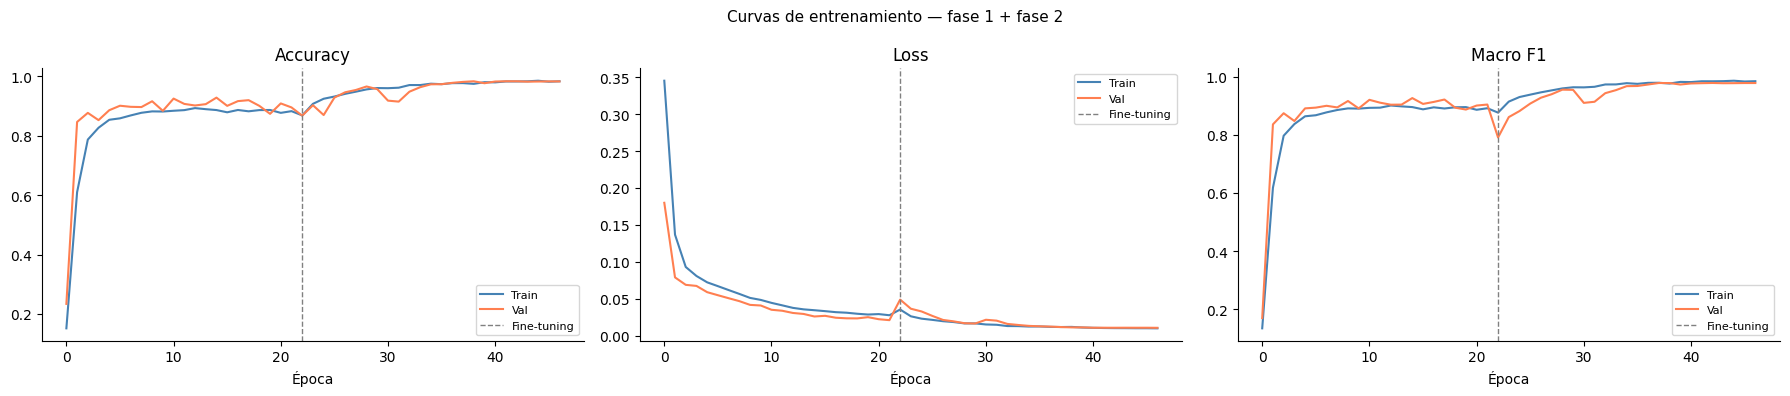

In [ ]:
def plot_history(h1, h2):
    # busca la clave de accuracy automáticamente
    acc_key = next(k for k in h1.history if 'accuracy' in k and not k.startswith('val'))
    val_acc_key = 'val_' + acc_key

    acc   = h1.history[acc_key]    + h2.history[acc_key]
    val   = h1.history[val_acc_key] + h2.history[val_acc_key]
    loss  = h1.history['loss']     + h2.history['loss']
    vloss = h1.history['val_loss'] + h2.history['val_loss']
    f1    = h1.history['macro_f1'] + h2.history['macro_f1']
    vf1   = h1.history['val_macro_f1'] + h2.history['val_macro_f1']
    sep   = len(h1.history[acc_key])

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for ax, train_m, val_m, title in zip(
        axes,
        [acc,  loss,  f1],
        [val,  vloss, vf1],
        ['Accuracy', 'Loss', 'Macro F1']
    ):
        ax.plot(train_m, label='Train', color='steelblue')
        ax.plot(val_m,   label='Val',   color='coral')
        ax.axvline(sep, color='gray', linestyle='--', linewidth=1, label='Fine-tuning')
        ax.set_title(title)
        ax.set_xlabel('Época')
        ax.legend(fontsize=8)
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('Curvas de entrenamiento — fase 1 + fase 2', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history1, history2)

## 11. Evaluación en test — métricas completas

REPORTE DE CLASIFICACION - TEST SET (KERAS FLOAT32)
                precision    recall  f1-score   support

  early_blight     0.9469    0.9661    0.9564       443
       healthy     0.9766    0.9330    0.9543       179
   late_blight     0.9860    0.9769    0.9814       433
leafroll_virus     0.9760    0.9919    0.9839       123
  mosaic_virus     0.9621    0.9845    0.9732       129
      nematode     0.9765    1.0000    0.9881        83
          pest     0.9007    0.8759    0.8881       145
   z_no_potato     1.0000    1.0000    1.0000       196

      accuracy                         0.9665      1731
     macro avg     0.9656    0.9660    0.9657      1731
  weighted avg     0.9665    0.9665    0.9664      1731



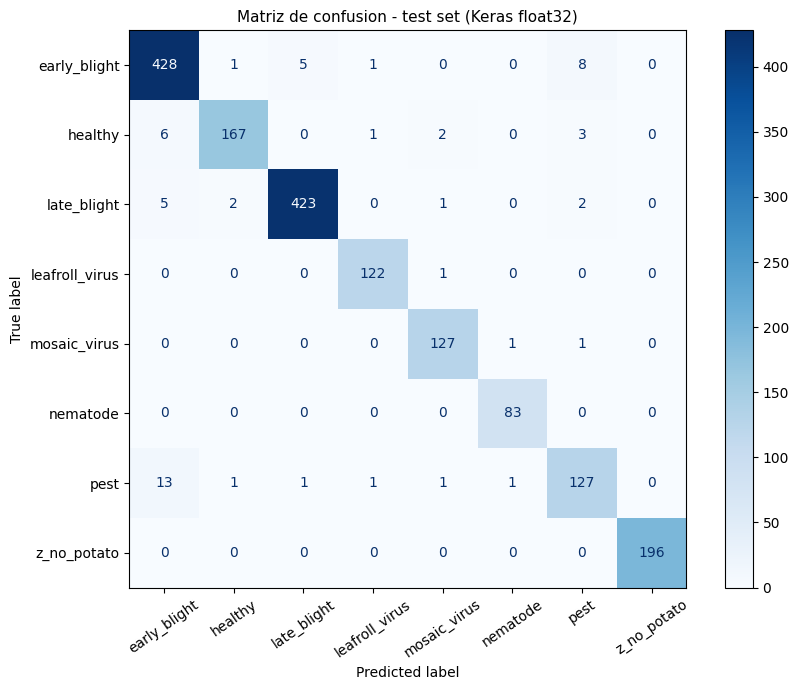


Resumen de auditoria por imagen:
  Total evaluadas: 1731
  Aciertos       : 1673
  Errores        : 58

Primeras 20 predicciones:


,filename,path,true_label,pred_label,confidence,correct
0,IMG_20230816_141633.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,pest,early_blight,0.569559,False
1,000000304093.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,z_no_potato,z_no_potato,0.999543,True
2,early blight (40).JPG,/kaggle/input/datasets/kevinvichicela/potato4/...,early_blight,early_blight,0.999108,True
3,57625493-7f34-47eb-b7d4-591b39701edc___R.S_HL ...,/kaggle/input/datasets/kevinvichicela/potato4/...,z_no_potato,z_no_potato,0.992655,True
4,plant pests (153).jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,pest,pest,0.852832,True
5,healthy (33)__dataset5_shahadhossin.JPG,/kaggle/input/datasets/kevinvichicela/potato4/...,healthy,healthy,0.992776,True
6,Late_Blight (599).jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,late_blight,late_blight,0.980873,True
7,potato virus (357).jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,mosaic_virus,mosaic_virus,0.967734,True
8,69389.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,healthy,healthy,0.951760,True
9,IMG_20230816_081552.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,pest,early_blight,0.613663,False



Primeros 30 errores (si existen):


,filename,path,true_label,pred_label,confidence,correct
0,late blight (147).JPG,/kaggle/input/datasets/kevinvichicela/potato4/...,late_blight,healthy,0.974277,False
1,20230816_085819.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,pest,nematode,0.964680,False
2,20230802_124933.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,pest,early_blight,0.870884,False
3,IMG_9416.JPG,/kaggle/input/datasets/kevinvichicela/potato4/...,early_blight,leafroll_virus,0.844392,False
4,1692334247132.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,pest,early_blight,0.827039,False
5,20230802_104815324.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,early_blight,pest,0.793012,False
6,IMG_20230815_123024~2.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,early_blight,pest,0.759434,False
7,67867.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,early_blight,late_blight,0.746414,False
8,20230712_154637.jpg,/kaggle/input/datasets/kevinvichicela/potato4/...,early_blight,late_blight,0.736071,False
9,IMG_4654.JPG,/kaggle/input/datasets/kevinvichicela/potato4/...,healthy,pest,0.724436,False



CSV exportados:
  - /kaggle/working/keras_test_predictions.csv
  - /kaggle/working/keras_test_errors.csv


In [ ]:
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Auditoria detallada por imagen para saber en cuales falla el modelo
records_eval = []
y_true, y_pred = [], []

for path, true_label in zip(test_paths, test_labels):
    true_idx = class_to_idx[true_label]
    arr, _ = load_and_preprocess(path, true_idx, augment=False)
    probs = model.predict(np.expand_dims(arr, 0), verbose=0)[0]

    pred_idx = int(np.argmax(probs))
    pred_label = idx_to_class[pred_idx]
    conf = float(probs[pred_idx])

    y_true.append(true_idx)
    y_pred.append(pred_idx)

    records_eval.append({
        'filename': Path(path).name,
        'path': path,
        'true_label': true_label,
        'pred_label': pred_label,
        'confidence': conf,
        'correct': pred_label == true_label,
    })

print('=' * 60)
print('REPORTE DE CLASIFICACION - TEST SET (KERAS FLOAT32)')
print('=' * 60)
print(classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=35)
ax.set_title('Matriz de confusion - test set (Keras float32)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla completa de predicciones y subset de errores
df_test_predictions = pd.DataFrame(records_eval)
df_test_errors = (
    df_test_predictions[~df_test_predictions['correct']]
    .sort_values('confidence', ascending=False)
    .reset_index(drop=True)
)

print('\nResumen de auditoria por imagen:')
print(f"  Total evaluadas: {len(df_test_predictions)}")
print(f"  Aciertos       : {int(df_test_predictions['correct'].sum())}")
print(f"  Errores        : {len(df_test_errors)}")

print('\nPrimeras 20 predicciones:')
display(df_test_predictions.head(20))

print('\nPrimeros 30 errores (si existen):')
display(df_test_errors.head(30))

pred_csv_path = OUTPUT_DIR / 'keras_test_predictions.csv'
err_csv_path = OUTPUT_DIR / 'keras_test_errors.csv'
df_test_predictions.to_csv(pred_csv_path, index=False, encoding='utf-8-sig')
df_test_errors.to_csv(err_csv_path, index=False, encoding='utf-8-sig')

print('\nCSV exportados:')
print(f'  - {pred_csv_path}')
print(f'  - {err_csv_path}')

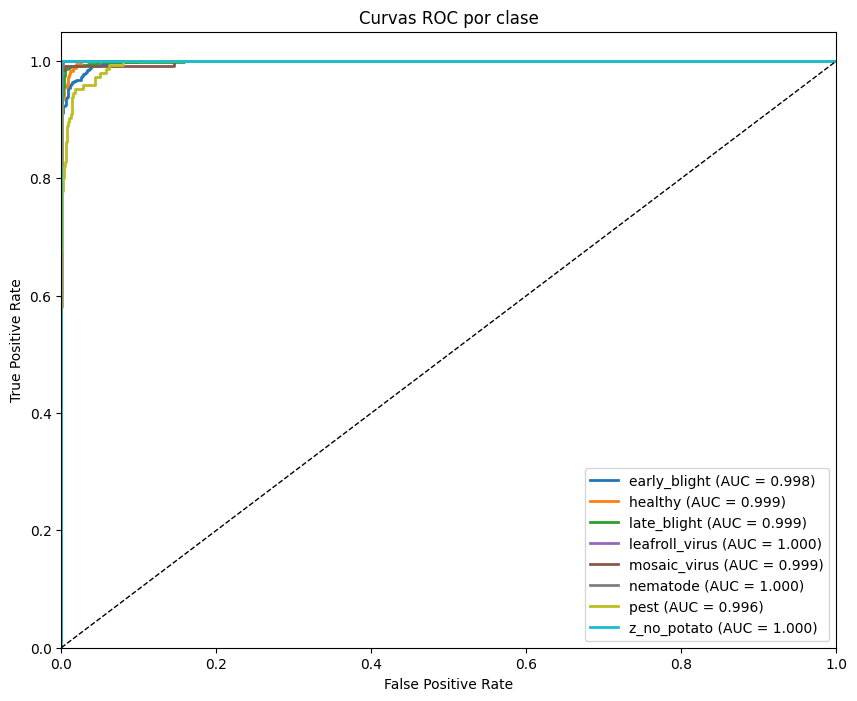

AUC macro promedio: 0.9989


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Obtener todas las probabilidades y etiquetas verdaderas del test set
y_true_all = []
y_score_all = []
for batch_imgs, batch_labels in test_ds:
    preds = model.predict(batch_imgs, verbose=0)
    y_score_all.extend(preds)
    y_true_all.extend(batch_labels.numpy())
y_true_all = np.array(y_true_all)
y_score_all = np.array(y_score_all)

# Binarizar las etiquetas (one‑hot) para calcular ROC por clase
y_true_bin = label_binarize(y_true_all, classes=range(NUM_CLASSES))

# Calcular ROC y AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score_all[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Dibujar todas las curvas
plt.figure(figsize=(10,8))
colors = plt.colormaps.get_cmap('tab10')(np.linspace(0, 1, NUM_CLASSES))
for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{classes[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150)
plt.show()

# AUC macro promedio
macro_auc = np.mean(list(roc_auc.values()))
print(f"AUC macro promedio: {macro_auc:.4f}")

## 12. Exportación a TFLite (int8)
> **Cambio:** calibración con 300 imágenes (era 100) para reducir degradación de accuracy en cuantización.

In [ ]:
# MEJORA: 300 imágenes para calibración int8 (era 100).
# Más imágenes → mejor estimación de rangos de activación → menor degradación de accuracy.
def representative_dataset():
    count = 0
    for img_batch, _ in val_ds:
        for img in img_batch:
            yield [tf.expand_dims(img, 0)]
            count += 1
            if count >= 300:   # era 100
                return

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.uint8
converter.inference_output_type = tf.uint8

tflite_model = converter.convert()
tflite_path  = OUTPUT_DIR / 'potato_classifier_v2.tflite'
tflite_path.write_bytes(tflite_model)

labels_path = OUTPUT_DIR / 'labels.txt'
with open(labels_path, 'w') as f:
    f.write('\n'.join(classes))

size_mb = tflite_path.stat().st_size / 1_048_576
print(f'Modelo TFLite guardado: {tflite_path}')
print(f'Etiquetas guardadas en: {labels_path}')
print(f'Tamaño del modelo: {size_mb:.2f} MB')


INFO:tensorflow:Assets written to: /tmp/tmp_4m0ya_5/assets


INFO:tensorflow:Assets written to: /tmp/tmp_4m0ya_5/assets


Saved artifact at '/tmp/tmp_4m0ya_5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  136112981834064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136112981832912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136112981835408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136112981834640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136112981834256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136112981832720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136112981834832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136112981833104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136112981835216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136112981835600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1361129818

W0000 00:00:1781307431.353338      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1781307431.353394      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1781307431.523249      58 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


Modelo TFLite guardado: /kaggle/working/potato_classifier_v2.tflite
Etiquetas guardadas en: /kaggle/working/labels.txt
Tamaño del modelo: 2.94 MB


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [ ]:
from sklearn.metrics import accuracy_score

# Cargar el modelo TFLite exportado
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

in_scale, in_zero_point = input_details['quantization']
out_scale, out_zero_point = output_details['quantization']

print('Entrada TFLite:', input_details['dtype'], input_details['shape'], input_details['quantization'])
print('Salida TFLite :', output_details['dtype'], output_details['shape'], output_details['quantization'])


def run_tflite_int8_single(img_float_m1_1):
    """
    img_float_m1_1: np.ndarray [H,W,3] normalizada en [-1, 1]
    Retorna probs float32 des-cuantizadas.
    """
    x = np.expand_dims(img_float_m1_1, axis=0).astype(np.float32)

    # Cuantizar entrada float -> uint8 usando parametros del tensor de entrada
    if in_scale > 0:
        x_q = np.round(x / in_scale + in_zero_point)
    else:
        x_q = x
    x_q = np.clip(x_q, 0, 255).astype(np.uint8)

    interpreter.set_tensor(input_details['index'], x_q)
    interpreter.invoke()
    y_q = interpreter.get_tensor(output_details['index'])

    # Des-cuantizar salida uint8 -> float
    if out_scale > 0:
        y = (y_q.astype(np.float32) - out_zero_point) * out_scale
    else:
        y = y_q.astype(np.float32)

    return y[0]


# Evaluacion del TFLite en el mismo test set
y_true_tflite, y_pred_tflite = [], []
for path, true_label in zip(test_paths, test_labels):
    true_idx = class_to_idx[true_label]
    arr, _ = load_and_preprocess(path, true_idx, augment=False)
    probs = run_tflite_int8_single(arr)
    pred_idx = int(np.argmax(probs))

    y_true_tflite.append(true_idx)
    y_pred_tflite.append(pred_idx)

acc_tflite = accuracy_score(y_true_tflite, y_pred_tflite)

# Accuracy Keras float ya calculada antes (si no existe, la recalculamos rapido)
if 'y_true' in globals() and 'y_pred' in globals() and len(y_true) == len(y_pred):
    acc_keras = accuracy_score(y_true, y_pred)
else:
    y_true_keras, y_pred_keras = [], []
    for batch_imgs, batch_labels in test_ds:
        preds = model.predict(batch_imgs, verbose=0)
        y_pred_keras.extend(np.argmax(preds, axis=1))
        y_true_keras.extend(batch_labels.numpy())
    acc_keras = accuracy_score(y_true_keras, y_pred_keras)

print('\n' + '=' * 65)
print('COMPARACION DE ACCURACY EN TEST')
print('=' * 65)
print(f'Keras (float32): {acc_keras:.4f}')
print(f'TFLite (int8) : {acc_tflite:.4f}')
print(f'Delta (int8 - float): {acc_tflite - acc_keras:+.4f}')
print('=' * 65)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Entrada TFLite: <class 'numpy.uint8'> [  1 224 224   3] (0.007843137718737125, 127)
Salida TFLite : <class 'numpy.uint8'> [1 8] (0.00390625, 0)

COMPARACION DE ACCURACY EN TEST
Keras (float32): 0.9665
TFLite (int8) : 0.9671
Delta (int8 - float): +0.0006


REPORTE TFLITE (INT8) - LISTO PARA TESIS

Metricas globales:


,metrica,valor
0,accuracy,0.967071
1,macro avg precision,0.963242
2,macro avg recall,0.969979
3,macro avg f1-score,0.966549
4,weighted avg precision,0.967213
5,weighted avg recall,0.967071
6,weighted avg f1-score,0.967093



Metricas por clase:


,clase,precision,recall,f1-score,support
0,early_blight,0.965596,0.950339,0.957907,443
1,healthy,0.944134,0.944134,0.944134,179
2,late_blight,0.983721,0.976905,0.980301,433
3,leafroll_virus,0.976000,0.991870,0.983871,123
4,mosaic_virus,0.954887,0.984496,0.969466,129
5,nematode,0.976190,0.987952,0.982036,83
6,pest,0.905405,0.924138,0.914676,145
7,z_no_potato,1.000000,1.000000,1.000000,196


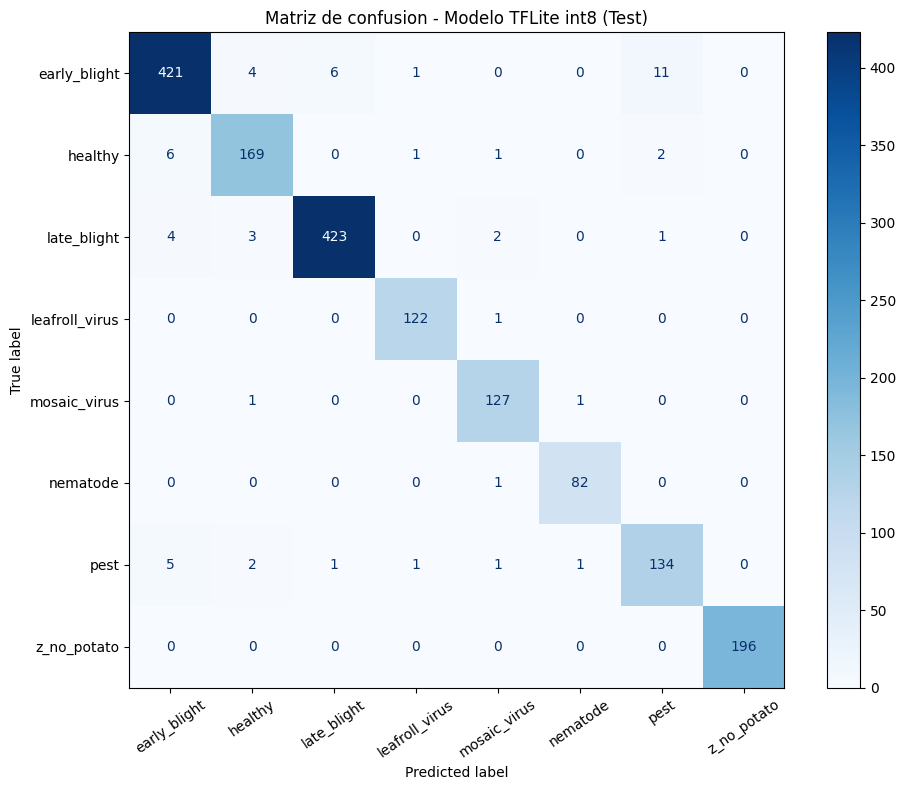


Archivos exportados:
  - /kaggle/working/tflite_report_per_class.csv
  - /kaggle/working/tflite_report_summary.csv
  - /kaggle/working/confusion_matrix_tflite.png


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# -----------------------------
# 1) Reporte de clasificacion
# -----------------------------
report_dict = classification_report(
    y_true_tflite,
    y_pred_tflite,
    target_names=classes,
    digits=4,
    output_dict=True,
    zero_division=0
)

# Tabla por clase
rows = []
for cls in classes:
    rows.append({
        'clase': cls,
        'precision': report_dict[cls]['precision'],
        'recall': report_dict[cls]['recall'],
        'f1-score': report_dict[cls]['f1-score'],
        'support': int(report_dict[cls]['support'])
    })

df_cls = pd.DataFrame(rows)

# Tabla de resumen
df_summary = pd.DataFrame([
    {
        'metrica': 'accuracy',
        'valor': float(report_dict['accuracy'])
    },
    {
        'metrica': 'macro avg precision',
        'valor': float(report_dict['macro avg']['precision'])
    },
    {
        'metrica': 'macro avg recall',
        'valor': float(report_dict['macro avg']['recall'])
    },
    {
        'metrica': 'macro avg f1-score',
        'valor': float(report_dict['macro avg']['f1-score'])
    },
    {
        'metrica': 'weighted avg precision',
        'valor': float(report_dict['weighted avg']['precision'])
    },
    {
        'metrica': 'weighted avg recall',
        'valor': float(report_dict['weighted avg']['recall'])
    },
    {
        'metrica': 'weighted avg f1-score',
        'valor': float(report_dict['weighted avg']['f1-score'])
    }
])

print('=' * 70)
print('REPORTE TFLITE (INT8) - LISTO PARA TESIS')
print('=' * 70)
print('\nMetricas globales:')
display(df_summary)
print('\nMetricas por clase:')
display(df_cls)

# -----------------------------
# 2) Matriz de confusion
# -----------------------------
cm_tflite = confusion_matrix(y_true_tflite, y_pred_tflite)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tflite, display_labels=classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=35)
ax.set_title('Matriz de confusion - Modelo TFLite int8 (Test)', fontsize=12)
plt.tight_layout()

cm_img_path = OUTPUT_DIR / 'confusion_matrix_tflite.png'
plt.savefig(cm_img_path, dpi=160, bbox_inches='tight')
plt.show()

# -----------------------------
# 3) Guardar tablas para tesis
# -----------------------------
cls_csv_path = OUTPUT_DIR / 'tflite_report_per_class.csv'
sum_csv_path = OUTPUT_DIR / 'tflite_report_summary.csv'

# Redondeo para reporte
df_cls_out = df_cls.copy()
df_cls_out[['precision', 'recall', 'f1-score']] = df_cls_out[['precision', 'recall', 'f1-score']].round(4)
df_summary_out = df_summary.copy()
df_summary_out['valor'] = df_summary_out['valor'].round(4)

df_cls_out.to_csv(cls_csv_path, index=False, encoding='utf-8-sig')
df_summary_out.to_csv(sum_csv_path, index=False, encoding='utf-8-sig')

print('\nArchivos exportados:')
print(f'  - {cls_csv_path}')
print(f'  - {sum_csv_path}')
print(f'  - {cm_img_path}')

## 13. Generación de Grad-CAM estáticos por clase
Se calcula el mapa de activación de la última capa conv de MobileNetV2 para una imagen
representativa de cada clase. Estos mapas se empaquetan en el APK como recursos estáticos —
latencia extra en inferencia: 0 ms.

In [ ]:
import matplotlib as mpl
import numpy as np
import matplotlib as mpl
from PIL import Image

last_conv_layer = None
for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer = layer
        break

if last_conv_layer is None:
    raise ValueError("No se encontró ninguna capa Conv2D en base_model")

print("Usando capa:", last_conv_layer.name)
print("Output shape:", last_conv_layer.output.shape)

# Submodelo interno: base_model.input → (base_model.output, conv_outputs)
# Evita el problema de Graph disconnected al no cruzar el límite base→model
base_grad_model = tf.keras.Model(
    inputs=base_model.inputs,
    outputs=[base_model.output, last_conv_layer.output]
)

# Capas superiores del modelo principal (fuera de la base)
gap_layer     = model.get_layer('global_average_pooling2d')
dropout_layer = model.get_layer('dropout')
dense_layer   = model.get_layer('dense_1')

# Verificación
print("\nVerificación base_grad_model:")
print("  Input shape :", base_grad_model.input_shape)
print("  Output[0]   :", base_grad_model.output[0].shape, "← base output")
print("  Output[1]   :", base_grad_model.output[1].shape, "← conv activations")

gap_layer     = next(l for l in model.layers if 'global_average_pooling' in l.name)
dense1_layer  = next(l for l in model.layers 
                     if 'dense' in l.name and l.output.shape[-1] == 256)
bn_layer      = next(l for l in model.layers if 'batch_normalization' in l.name)
dropout1_layer= next(l for l in model.layers if l.name == 'dropout')
dense2_layer  = next(l for l in model.layers 
                     if 'dense' in l.name and l.output.shape[-1] == 128)
dropout2_layer= next(l for l in model.layers if l.name == 'dropout_1')
dense_out     = next(l for l in model.layers 
                     if 'dense' in l.name and l.output.shape[-1] == NUM_CLASSES)

def compute_gradcam(img_array, class_idx):
    img_tensor = tf.cast(tf.expand_dims(img_array, 0), tf.float32)

    with tf.GradientTape() as tape:
        base_out, conv_outputs = base_grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)
        # Forward pass completo por la cabeza
        x = gap_layer(base_out)
        x = dense1_layer(x)
        x = bn_layer(x, training=False)
        x = dropout1_layer(x, training=False)
        x = dense2_layer(x)
        x = dropout2_layer(x, training=False)
        preds = dense_out(x)
        class_score = preds[:, class_idx]

    grads = tape.gradient(class_score, conv_outputs)

    if grads is None:
        raise ValueError(f"Gradientes None para clase {class_idx}.")

    weights  = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam      = tf.reduce_sum(tf.multiply(weights, conv_outputs[0]), axis=-1)
    cam      = tf.maximum(cam, 0)
    cam_np   = cam.numpy()
    cam_max  = np.max(cam_np)
    cam_min  = np.min(cam_np)

    if (cam_max - cam_min) > 1e-8:
        cam_np = (cam_np - cam_min) / (cam_max - cam_min)
    else:
        cam_np = np.zeros_like(cam_np)

    cam_img = Image.fromarray((cam_np * 255).astype(np.uint8))
    cam_img = cam_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    return np.array(cam_img) / 255.0

def overlay_heatmap(original_arr: np.ndarray,
                    heatmap: np.ndarray,
                    color_alpha: float = 0.6) -> np.ndarray: # CAMBIADO DE alpha A color_alpha
    """Superpone el heatmap coloreado (jet) sobre la imagen original."""

    orig_uint8 = ((original_arr + 1.0) * 127.5).astype(np.uint8)
    orig_img = Image.fromarray(orig_uint8).convert("RGBA")
    
    colormap = mpl.colormaps['jet']
    heatmap_rgb = (colormap(heatmap)[:, :, :3] * 255).astype(np.uint8)
    
    dynamic_alpha = np.power(heatmap, 1.5) 
    
    dynamic_alpha = dynamic_alpha * color_alpha
    
    alpha_mask_uint8 = (dynamic_alpha * 255).astype(np.uint8)
    
    rgba_heatmap_np = np.dstack((heatmap_rgb, alpha_mask_uint8))
    heatmap_img = Image.fromarray(rgba_heatmap_np, "RGBA")
    
    blended_img = Image.alpha_composite(orig_img, heatmap_img)
    
    return np.array(blended_img.convert("RGB"))

print('\nFunciones Grad-CAM listas.')

Usando capa: Conv_1
Output shape: (None, 7, 7, 1280)

Verificación base_grad_model:
  Input shape : (None, 224, 224, 3)
  Output[0]   : (None, 7, 7, 1280) ← base output
  Output[1]   : (None, 7, 7, 1280) ← conv activations

Funciones Grad-CAM listas.


In [ ]:
# Buscar las TOP 3 imágenes de test con mayor confianza por clase
TOP_N = 3
gradcam_dir = OUTPUT_DIR / 'gradcam_static'
gradcam_dir.mkdir(exist_ok=True)

# Ahora guardamos una lista de resultados por clase, no solo uno
top_per_class = {i: [] for i in range(NUM_CLASSES)}

print("Analizando imágenes y recolectando candidatos...")
for path, true_label in zip(test_paths, test_labels):
    true_idx = class_to_idx[true_label]
    arr, _   = load_and_preprocess(path, true_idx, augment=False)
    preds    = model.predict(np.expand_dims(arr, 0), verbose=0)[0]
    pred_idx = np.argmax(preds)
    conf     = float(preds[pred_idx])
    
    # Solo candidatos correctamente clasificados y evitando la saturación del 1.0 absoluto
    if pred_idx == true_idx and conf < 0.99:
        top_per_class[true_idx].append({'conf': conf, 'path': path, 'arr': arr})

# Generar y guardar los Grad-CAM en la carpeta
print(f"\nGenerando y guardando las mejores {TOP_N} imágenes por clase...")
for cls_idx, cls_name in enumerate(classes):
    
    # Ordenamos todas las imágenes de esta clase de mayor a menor confianza
    # y nos quedamos solo con la cantidad definida en TOP_N
    candidates = sorted(top_per_class[cls_idx], key=lambda x: x['conf'], reverse=True)[:TOP_N]
    
    if not candidates:
        print(f'  AVISO: no se encontraron imágenes para {cls_name}')
        continue
        
    print(f"  -> Guardando {len(candidates)} opciones para {cls_name}...")
    
    for rank, info in enumerate(candidates):
        arr     = info['arr']
        heatmap = compute_gradcam(arr, cls_idx)
        overlay = overlay_heatmap(arr, heatmap)

        # Guardar directamente la imagen procesada con un nombre descriptivo
        # Ejemplo: gradcam_late_blight_top1_conf0.985.jpg
        filename = f'gradcam_{cls_name}_top{rank+1}_conf{info["conf"]:.3f}.jpg'
        out_path = gradcam_dir / filename
        Image.fromarray(overlay).save(str(out_path), quality=90)

print(f'\n¡Proceso terminado!')
print(f'Ve al panel derecho de Kaggle, entra a la carpeta: {gradcam_dir}')
print('Ahí tendrás todas las imágenes listas para descargar y elegir la mejor.')

Analizando imágenes y recolectando candidatos...

Generando y guardando las mejores 3 imágenes por clase...
  -> Guardando 3 opciones para early_blight...
  -> Guardando 3 opciones para healthy...
  -> Guardando 3 opciones para late_blight...
  -> Guardando 3 opciones para leafroll_virus...
  -> Guardando 3 opciones para mosaic_virus...
  -> Guardando 3 opciones para nematode...
  -> Guardando 3 opciones para pest...
  -> Guardando 3 opciones para z_no_potato...

¡Proceso terminado!
Ve al panel derecho de Kaggle, entra a la carpeta: /kaggle/working/gradcam_static
Ahí tendrás todas las imágenes listas para descargar y elegir la mejor.


## 14. Resumen de archivos generados

In [ ]:
print('=' * 55)
print('ARCHIVOS GENERADOS')
print('=' * 55)

outputs = [
    OUTPUT_DIR / 'potato_classifier.tflite',
    OUTPUT_DIR / 'best_phase2.keras',
    OUTPUT_DIR / 'training_curves.png',
    OUTPUT_DIR / 'confusion_matrix.png',
    OUTPUT_DIR / 'gradcam_all_classes.png',
]
outputs += list(gradcam_dir.glob('*.jpg'))

for f in outputs:
    if Path(f).exists():
        size = Path(f).stat().st_size / 1024
        print(f'  {Path(f).name:<40} {size:>8.1f} KB')
    else:
        print(f'  {Path(f).name:<40}  NO ENCONTRADO')

print('=' * 55)
print()
print('Para Android necesitas:')
print('  1. potato_classifier.tflite  → /assets/ en el proyecto Android')
print('  2. gradcam_*.jpg             → /res/drawable/ en el proyecto Android')
print()
print('class_to_idx (para el clasificador en Kotlin):')
for cls, idx in class_to_idx.items():
    print(f'  {idx}: "{cls}"')

ARCHIVOS GENERADOS
  potato_classifier.tflite                  NO ENCONTRADO
  best_phase2.keras                         26383.0 KB
  training_curves.png                         103.2 KB
  confusion_matrix.png                         96.1 KB
  gradcam_all_classes.png                   NO ENCONTRADO
  gradcam_healthy_top2_conf0.989.jpg           15.5 KB
  gradcam_early_blight_top2_conf0.990.jpg      17.9 KB
  gradcam_leafroll_virus_top2_conf0.959.jpg      9.4 KB
  gradcam_z_no_potato_top2_conf0.980.jpg        8.3 KB
  gradcam_nematode_top1_conf0.990.jpg          12.3 KB
  gradcam_late_blight_top3_conf0.990.jpg       11.2 KB
  gradcam_nematode_top2_conf0.987.jpg          12.6 KB
  gradcam_pest_top1_conf0.990.jpg              13.4 KB
  gradcam_z_no_potato_top3_conf0.977.jpg        9.4 KB
  gradcam_leafroll_virus_top1_conf0.961.jpg     12.8 KB
  gradcam_leafroll_virus_top3_conf0.957.jpg      8.5 KB
  gradcam_z_no_potato_top1_conf0.987.jpg        7.7 KB
  gradcam_mosaic_virus_top3_conf0.989